# Regression with discrete variables

## Data set  
The possum.csv data set includes measures from 104 possums that were caught in New Zealand in a field study. 
Variables: 
-	site: The site number where the possum was trapped.
-	pop: Population, either Vic (Victoria) or other (New South Wales or Queensland).
-	sex: Gender, either m (male) or f (female).
-	age: Age in years
-	headL: Head length, in mm.
-	skullW: Skull width, in mm.
-	totalL: Total length, in cm.
-	tailL: Tail length, in cm.

## Preliminaries
Set up the environment by importing pandas, numpy, and matplotlib, scipy.optimize. This is already done in the preliminaries. 

In [ ]:
import matplotlib
import matplotlib.pyplot as plt
import scipy.optimize as so
import pandas as pd
import numpy as np

In [ ]:
def multRegPredict(b,D,xname,returnDeriv=False):
    """Model prediction function for multiple regression.
    If returnDeriv is True, it returns the derivative of the predicted values with respect to the parameters (i.e., the Jacobian matrix).

    Args:
        b (array): Q+1 regression coefficients for Q variables
        D (pd.DataFrame): Data frame
        xname (list): Names of the Q explanatory variables
    Returns:
        yp (array): predicted y-values
        deriv (np.array,optional): derivative of predicted values with respect to the parameters (N x K matrix)
    """
    yp=np.ones(len(D.index))*b[0]        # Intercept
    for i in range(len(xname)):
        yp=yp+D[xname[i]].values*b[i+1]         # Add each regression value
    if returnDeriv:
        deriv = np.ones((len(D.index),1))
        for i in range(len(xname)):
            deriv = np.c_[deriv,D[xname[i]]]         # Add each regression value
        return yp,deriv
    return yp

def RSSloss(b,y,predictfcn,args=(), returnDeriv=False):
    """Loss function for regression based on the residual sum of squares (RSS).

    Args:
        b (array): Parameters of the model
        y (array): Actual response variable values
        predictfcn (function): Function that takes (b, *args) and returns predicted
        args (tuple): Additional arguments to the prediction function
        returnDeriv (bool): If True, also return the gradient of the loss with respect

    Returns:
        loss (float): The residual sum of squares
        grad (array, optional): The gradient of the loss with respect to the parameters (if returnDeriv is True)
    """
    if (returnDeriv):
        predY,deriv = predictfcn(b,*args,returnDeriv=True)
        res = np.array(y-predY)
        rss = sum(res**2)
        # The derivative of the RSS with respect to b
        grad = -2 * np.sum(res.reshape(-1,1) * deriv,axis=0)
        return rss,grad
    predY = predictfcn(b,*args)
    res = y-predY
    rss = sum(res**2)
    return rss

def fit_multReg(D,y,xname=[],figure=False,b0=[]):
    """Fits a multiple regression loss function

    Args:
        D (pd.DataFrame): Pandas data frame with explanatory variables
        y (ndarray): Dependent variable
        xname (list): List of strings with names of explanatory variables
        figure (int): Plot figure? Defaults to 0.
        b0 (np.ndarray). Initial guess for the parameter vector

    Returns:
        R2: Fitted R2 value
        b: Fitted
    """
    k=len(xname)+1
    if (len(b0)!=k):
        b0=np.zeros((k,))
    RES = so.minimize(RSSloss,b0,args=(y,multRegPredict,(D,xname),True),jac=True)
    b=RES.x # Results
    TSS = sum((y-np.mean(y))**2)
    yp = multRegPredict(b,D,xname)
    RSS = sum((y-yp)**2)
    R2 = 1-RSS/TSS
    if (k==2 and figure):
        fig = plt.figure()
        ax = fig.add_subplot(1,1,1)
        ax.scatter(D[xname[0]],y)
        xRange=[min(D[xname[0]]),max(D[xname[0]])]
        xp=np.arange(xRange[0],xRange[1],(xRange[1]-xRange[0])/50)
        yp=b[0]+b[1]*xp
        ax.plot(xp,yp,'r-')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
    return (b,R2)


def leaveOneOutCV_df(D,y,xname,fitfcn=fit_multReg,predictfcn=multRegPredict):
    N = len(y) #Number of observations
    yp= np.zeros(N)
    ind = np.arange(N)
    for i in range(N):
        b,R2=fitfcn(D[ind!=i],y[ind!=i],xname)
        yp[i]=predictfcn(b,D[ind==i],xname)[0]
    TSS  = sum((y-y.mean())**2)
    RSS = sum((y-yp)**2)
    R2cv = 1-RSS/TSS
    return R2cv

def bootstrapReg(D,y,xname,fitfcn=fit_multReg,numIter=500):
    # Get original parameter estimates to establish number of parameters
    b,R2=fitfcn(D,y,xname)
    numParams=len(b)
    # Length of data
    N = len(D.index)
    ind  = np.arange(N)
    stats = np.zeros((numIter,numParams))
    for i in range(numIter):
        sample=np.random.choice(ind,N)
        stats[i,:],R2=fitfcn(D.iloc[sample],y[sample],xname)
    return stats

def confidenceInt(data,perc):
    tail = (100-perc)/2 # Weight on each tail
    Int=(np.percentile(data,tail),np.percentile(data,100-tail))
    return Int

## Task 1: Discrete predictor variables

### Question 1.1 
Load the data set possum.csv. 
Generate 3 new columns in the data frame: 
- bodyL: The length of the main body (totalL - tailL) 
- popI:  Population identifier, 0: if pop is 'other', 1: if pop is 'Vic'
- sexI:  Sex indentifier, 0: if sex is 'm', 1: if sex is 'f'

Use your function `fit_multReg` from above to run a regression analysis of bodyL (response variable) against sexI (explanatory variable). Make a plot (with labeled axes) that show sex on the x-axis and body length on the y axis. Add the prediction line from the regression. 

Text(0.5, 1.0, 'Body Length vs. Sex Identifier')

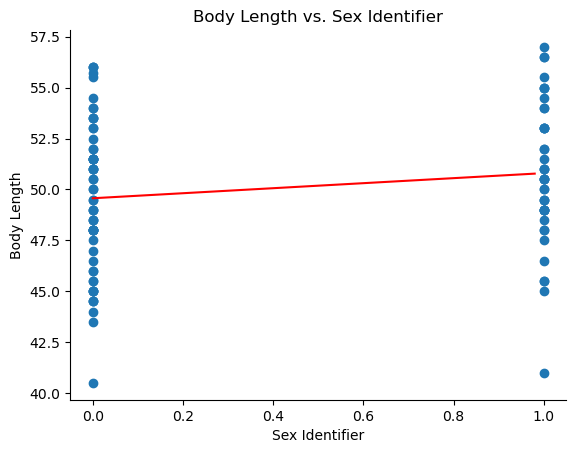

In [ ]:
df = pd.read_csv("possum.csv")
df['bodyL'] = df['totalL'] - df['tailL']
df['popI'] = np.double(df['pop'] == 'Vic')
df['sexI'] = np.double(df['sex'] == 'f')
b, R2 = fit_multReg(df, df['bodyL'], ['sexI'], True)
plt.xlabel("Sex Identifier")
plt.ylabel("Body Length")
plt.title("Body Length vs. Sex Identifier")

>Plot of Body Length vs. Sex Identifier

### Question 1.2 
Use boostrap to estimate a 95% confidence interval on the regression parameter of sex as a explanatory variable for body length. Report the confidence interval. Does the confidence interval include 0? What does this mean for the relationship between sex and body length?

In [ ]:
stats = bootstrapReg(df, df['bodyL'], ['sexI'])
confidenceInt(stats[:, 1], 95)

(np.float64(-0.07929831855138161), np.float64(2.6860421286031055))

>Yes, this CI includes 0 which means that sex is not a significant predictor of body length.

### Question 1.3 
Make a scatter plot of age (x-axis) against body length (y-axis), with male and female possums shown in different colors. 
You can do this by plotting two scatter plots sequentially - each time selecting either male or female possums. The second one will simply add points in a different color to the first plot.  

Estimate a multiple regression model that explains bodyL as a function of age and sex. What is the R2-value? 

Get the predicted values from the regression, and plot the predicted values in the same graph seperately for male and female possums. 

0.08543037213506488


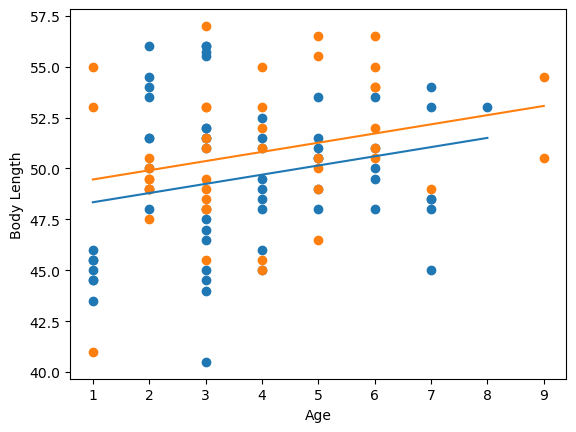

In [ ]:
plt.scatter(df['age'].loc[df['sexI']==0], df['bodyL'].loc[df['sexI']==0])
plt.scatter(df['age'].loc[df['sexI']==1], df['bodyL'].loc[df['sexI']==1])
plt.xlabel("Age")
plt.ylabel("Body Length")
b, R2 = fit_multReg(df, df['bodyL'], ['sexI', 'age'])
print(R2)
yp = multRegPredict(b, df, ['sexI', 'age'])
plt.plot(df['age'].loc[df['sexI']==0].sort_values(), yp[df['sexI']==0][df['age'].loc[df['sexI']==0].argsort()])
plt.plot(df['age'].loc[df['sexI']==1].sort_values(), yp[df['sexI']==1][df['age'].loc[df['sexI']==1].argsort()])

>Scatterplot of Body Length vs. Age & Predicted Values for Male & Female Possums

### Question 1.4 
Run a bootstrap analysis on the bodyL ~ age + sexI regression model. Report the 95% confidence interval for the regression parameters of sex and age on body length. How big is the effect of age onto body length in the context of the model? Does the confidence interval for the parameter include 0?


How big is the estimate of the effect of sex on body length? What is the CI? Does it include zero?   


In [ ]:
stats = bootstrapReg(df, df['bodyL'], ['sexI', 'age'])
print(confidenceInt(stats[:, 1], 95))
print(confidenceInt(stats[:, 2], 95))
print(np.mean(stats[:, 1]))
print(np.mean(stats[:, 2]))

(np.float64(-0.1996124654802729), np.float64(2.2702465782311694))
(np.float64(0.12790277437957978), np.float64(0.7916521691060533))
1.1069739632040305
0.45788229160283767


>The effect of age on body length is 0.44 cm/year and the CI for age does not include 0. The effect of sex on body length is 1.11 cm and the CI does include 0.

### Question 1.5 
Estimate a multiple regression model that explains bodyL as a function of age and population (Vic vs. other). What is the R2-value? Make a scatter plot like for Question 3, but this time splitting the data for the two populations, rather than based on sex. 

Which of the two population (Vic or other) has a larger mean body size? What is the mean differences in body size?  

Compare the mean difference in body size with the value of the regression coefficient for popI. Why are they not the same? 

In comparison to the simple mean difference in body size, how do you interpret the value of the regression coefficient for popI?  

0.17974517849498584
51.53260869565217
48.925862068965515
-2.6067466266866575


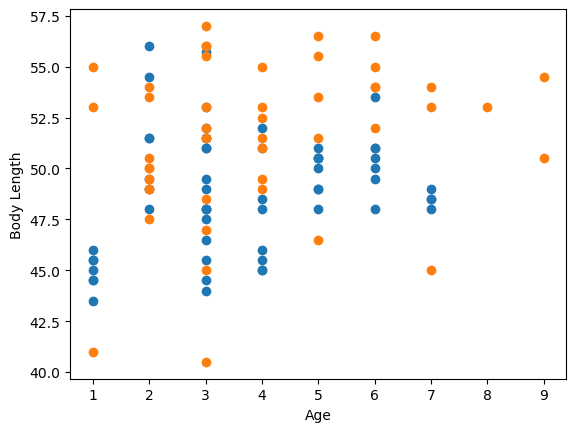

In [ ]:
b, R2 = fit_multReg(df, df['bodyL'], ['age', 'popI'])
print(R2)
plt.scatter(df['age'].loc[df['popI']==0], df['bodyL'].loc[df['popI']==0])
plt.scatter(df['age'].loc[df['popI']==1], df['bodyL'].loc[df['popI']==1])
plt.xlabel("Age")
plt.ylabel("Body Length")
mean_vic = df[df['popI'] == 1]['bodyL'].mean()
mean_other = df[df['popI'] == 0]['bodyL'].mean()
mean_diff = mean_other - mean_vic
print(mean_vic)
print(mean_other)
print(mean_diff)

>The Vic population has a larger mean body size. The mean differences in body size is 2.61 cm. The mean difference in body size and the R2 are not the same because the mean is confounded by age. The R2 of 0.18 means that for two possums that are the same age, the Vic population is 0.18 cm shorter than the other population.

### Question 1.6 
Run a bootstrap analysis on the bodyL ~ age + popI regression model. Report the 95% confidence interval for the regression parameters of popI and age on body length. In the *context of the model*, is there evidence for a positive effect of age onto body length? How about the relationship between population and body length? 


In [ ]:
stats = bootstrapReg(df, df['bodyL'], ['age', 'popI'])
print(confidenceInt(stats[:, 1], 95))
print(confidenceInt(stats[:, 2], 95))

(np.float64(0.08441523750979199), np.float64(0.7206744573452972))
(np.float64(1.2388631707186795), np.float64(3.785713502862368))


>Since the CI for age does not contain 0 so there is a positive effect of age onto body length. Since the CI for population also does not contain 0, there is a positive relationship between population and body length.

## Task 2: Discrete response variable
In this task we will investigate regression models in which the response variable is a discrete, dichotomous variable. 
### Question 2.1: Logistic Function 
Starting with your function for multRegPredict, write a function logisticRegPredict(b,D,xname). As inputs it should take the 
- b: np-array of regression coefficients (the first one being the intercept)
- D: Data frame
- xname: a list of column names (in D) that are being used as regressors. 

The function should first calculate a = b[0] + b[1] * D[xname[0]] + b[2] * D[xname[1]] + ... 
and then return the logistic function of a. 

Then make a Data frame with a single column with the values from -4 to 4 (in small steps). Plot the logistic function for the parameter values: 
- b = [0,0]
- b = [0,1]
- b = [0,2]
- b = [0,-2]

What happens as the slope value changes? 

Then plot the logistic function for the parameter values: 
- b = [0,2]
- b = [1,2]
- b = [2,2]
- b = [-2,2]

What happens as the intercept value changes? For each value - where does the predicted line cross p=0.5? 



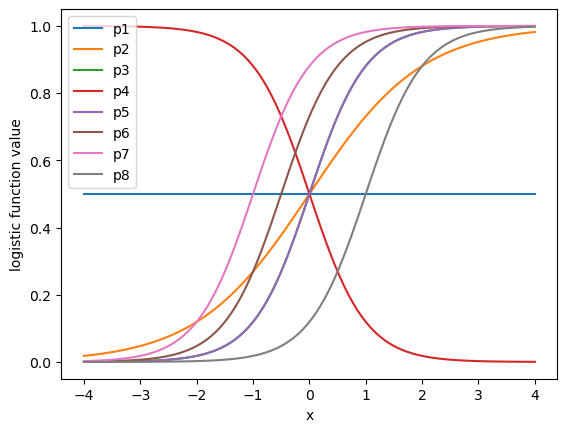

In [ ]:
def logisticRegPred(b, D, xname):
    an = np.ones(len(D.index)) * b[0]
    for i in range(len(xname)):
        an += b[i+1] * D[xname[i]]
    pn = 1 / (1 + np.exp(-an))
    return pn
    
entries = np.linspace(-4, 4, num=100)
Df = pd.DataFrame(entries, columns=['My Entries'])

p1 = logisticRegPred([0, 0], Df, ['My Entries'])
plt.plot(entries, p1, label="p1")
plt.xlabel("x")
plt.ylabel("logistic function value")

p2 = logisticRegPred([0, 1], Df, ['My Entries'])
plt.plot(entries, p2, label="p2")
plt.xlabel("x")
plt.ylabel("logistic function value")

p3 = logisticRegPred([0, 2], Df, ['My Entries'])
plt.plot(entries, p3, label="p3")
plt.xlabel("x")
plt.ylabel("logistic function value")

p4 = logisticRegPred([0, -2], Df, ['My Entries'])
plt.plot(entries, p4, label="p4")
plt.xlabel("x")
plt.ylabel("logistic function value")

p5 = logisticRegPred([0, 2], Df, ['My Entries'])
plt.plot(entries, p5, label="p5")
plt.xlabel("x")
plt.ylabel("logistic function value")

p6 = logisticRegPred([1, 2], Df, ['My Entries'])
plt.plot(entries, p6, label="p6")
plt.xlabel("x")
plt.ylabel("logistic function value")

p7 = logisticRegPred([2, 2], Df, ['My Entries'])
plt.plot(entries, p7, label="p7")
plt.xlabel("x")
plt.ylabel("logistic function value")

p8 = logisticRegPred([-2, 2], Df, ['My Entries'])
plt.plot(entries, p8, label="p8")
plt.xlabel("x")
plt.ylabel("logistic function value")

plt.legend()

>As the slope increases, the graph becomes steeper, and if it is negative, the graph goes from top left to bottom right. As the intercept increases, the graph moves to the left, and if it is negative, the graph moves to the right.

### Question 2.2 
Make a Scatterplot of tail length (as a x-variable) against popI (Population, 1:Victoria 0:other). 
Written answer: What relationship can you see? 


Text(0, 0.5, 'Population Identifier')

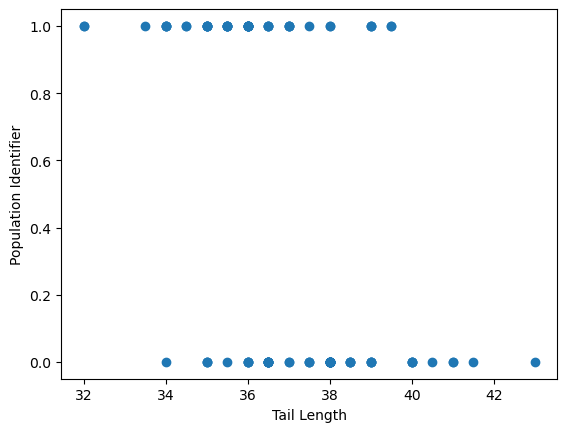

In [ ]:
plt.scatter(df['tailL'], df['popI'])
plt.xlabel("Tail Length")
plt.ylabel("Population Identifier")

>The relationship is that the Victoria population has smaller tail lengths than the other population.

### Question 2.3 
Now modify your prediction function, so it does not only return the prediction, but also the derivative of the prediction in respect to each of the parameters. 

```
def logisticRegPredict(b,D,xname,returnDeriv=False):
```

You should then test your function by calling it with: 

```
yp,deriv= logisticRegPredict([37,-1],D,['tailL'],returnDeriv=True)
```

The prediction value and the derivative for the first 2 data points should be: 

```
yp[0:2]=
array([0.73105858, 0.62245933])
deriv[0:2,:]=
array([[0.19661193, 7.0780296 ],
       [0.23500371, 8.5776355 ]])
```


In [ ]:
def logisticRegPredict(b,D,xname,returnDeriv=False):
    an = np.ones(len(D.index)) * b[0]
    for i in range(len(xname)):
        an += b[i+1] * D[xname[i]]
    pn = 1 / (1 + np.exp(-an))
    if returnDeriv:
        deriv = np.zeros((len(D), len(b)))
        deriv[:, 0] = pn * (1 - pn)
        for i in range(len(xname)):
            deriv[:, i+1] = pn * (1 - pn) * D[xname[i]]
        return pn, deriv
    return pn

yp,deriv= logisticRegPredict([37,-1],df,['tailL'],returnDeriv=True)
print(yp[0:2])
print(deriv[0:2,:])

0    0.731059
1    0.622459
Name: tailL, dtype: float64
[[0.19661193 7.0780296 ]
 [0.23500371 8.5776355 ]]


### Question 2.3 
Write a function `LogisticLoss(b,y,D,xnames,returnDeriv=False)` that calculates the Loss function for the logistic regression (negative log-likelihood, see lecture). The function should call logisticRegPredict to get the prediction and derivative, and then calculate the Loss and the gradient of the loss in respect to all regression parameters. The function should be able to use multiple regressors.    

Report the negative log likelihood (and derivates) for a logistic regression model that predicts popI as a function of tailL: 
- for the parameter values [0,0]
- for the parameter values [17.5,-0.5]
- for the parameter values [25.56,-0.7]

Which one is the best parameter setting of the three? 

In [ ]:
def LogisticLoss(b,y,D,xname,returnDeriv=False):    
    if returnDeriv:
        yp, derv = logisticRegPredict(b, D, xname, True)
        A = y * np.log(yp)
        B = (1 - y)
        C = np.log(1-yp)
        loss = -np.sum(A + B * C)
        grad = []
        res = y - yp
        grad.append(-sum(res))
        for i in range(len(xname)):
            grad.append(-np.sum(D[xname[i]] * res))
        return loss, grad
    else:
        yp = logisticRegPredict(b, D, xname, False)
        A = y * np.log(yp)
        B = (1 - y)
        C = np.log(1-yp)
        loss = -np.sum(A + B * C)
        return loss

l1, d1 = LogisticLoss([0, 0], df['popI'], df, ['tailL'], True)
print(l1)
print(d1)
l2, d2 = LogisticLoss([17.5, -0.5], df['popI'], df, ['tailL'], True)
print(l2)
print(d2)
l3, d3 = LogisticLoss([25.56, -0.7], df['popI'], df, ['tailL'], True)
print(l3)
print(d3)

72.0873067782343
[6.0, np.float64(271.5)]
63.01497836859197
[-14.659996419131037, np.float64(-527.4645090566933)]
56.72412770882329
[-0.3716007862586064, np.float64(-13.678461998498555)]


>The third parameter setting is the best because it has the lowest loss and the gradient is pretty close to zero.

### Question 2.5
Write a function `fit_logisticReg(D,y,xname,figure=True)` that fits the logistic model by minimizing the above Loss function. 
- D: A data frame with the explanatory variables 
- y: A dichotomous (0 or 1) response variable 
- xname: Names of x variables to be used 
- figure: Flag (True / False) indicating if the code should produce a figure. 
When there is only one x-variable, and figure==True, then function should produce a scatter plot of the data and the predicted values. 

The function should return the log-likelihood of the data under the best model and the best fitting (maximum liklihood) estimates of b. Remember that the function value you are minimizing is the *negative* log-likelihood, and the best fitting value is stored in RES.fun

Fit a logistic regression model that predicts popI as a function of tailL. Make sure the function generates a plot. Report log-likelihood and b-values. 

-56.7205157954412
[25.56620437 -0.69964061]


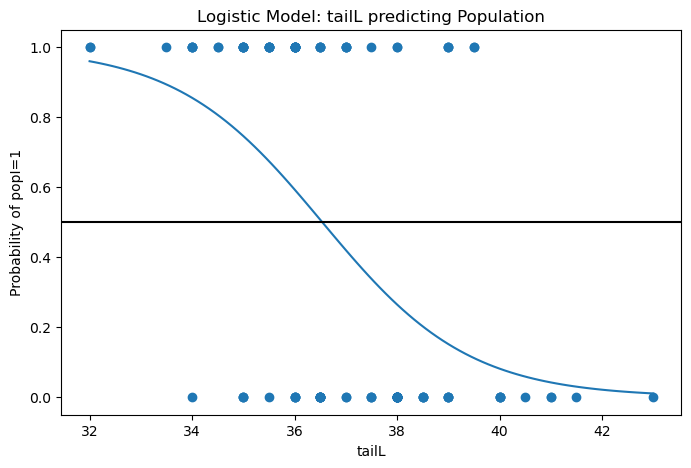

In [ ]:
def fit_logisticReg(D,y,xname,figure=True):
    b0 = np.zeros(len(xname) + 1)
    RES = so.minimize(LogisticLoss, b0, args=(y, D, xname, True), jac=True)
    b = RES.x
    l = -RES.fun
    if figure and len(xname) == 1:
        plt.figure(figsize=(8, 5))
        plt.scatter(D[xname[0]], y)
        x_min, x_max = D[xname[0]].min(), D[xname[0]].max()
        x_range = np.linspace(x_min, x_max, 100)
        plot_df = pd.DataFrame({xname[0]: x_range})
        y_prob = logisticRegPredict(b, plot_df, xname)
        plt.plot(x_range, y_prob)
        plt.axhline(0.5, color='black')
        plt.xlabel(xname[0])
        plt.ylabel('Probability of popI=1')
        plt.title(f'Logistic Model: {xname[0]} predicting Population')  
    return l, b

l1, b1 = fit_logisticReg(df, df['popI'], ['tailL'], figure=True)
print(l1)
print(b1)

### Question 2.6
Now fit the model explaing popI from tailL and bodyL in a multiple logistic regression model. Report the log-likelihood and parameter values. Is the fit better than tailL alone? 

Also fit the model explaing popI from tailL and totalL in a multiple logistic regression model. Again, report the log-likelihood and parameter values. 

What do you observe in terms of log-likelihood and in terms of paramters? Why do these two models yield exactly the same log-liklihood? 

In [ ]:
l2, b2 = fit_logisticReg(df, df['popI'], ['tailL', 'bodyL'], figure=True)
print(l2)
print(b2)
l3, b3 = fit_logisticReg(df, df['popI'], ['tailL', 'totalL'], figure=True)
print(l3)
print(b3)

-43.204635515835875
[16.57735312 -0.98846114  0.39180167]
-43.204635515835875
[16.5773531  -1.38026281  0.39180168]


>Yes, the fit is better than tail alone as the loss and the b is lower. The log likelihood and parameters is close to the fit of tailL and bodyL. These two models yield the same log likelihood because the totalL is just the linear combination of tailL and bodyL and no new information is being added to the model.